## BERTScore

In [10]:
from pathlib import Path
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [ ]:
BERTSCORE_INDIR = "./results/evaluation/bertscore/paraphrase-multilingual-mpnet-base-v2"
#BERTSCORE_INDIR = "./results/evaluation/bertscore/paraphrase-multilingual-miniLM-base-v2"
ROUGE_BLEU_INDIR = "./results/evaluation/rouege_bleu"

In [6]:
def resolve_dir(path_str: str) -> Path:
    """Resolve directory from common notebook working directories."""
    candidates = [
        Path(path_str),
        Path(path_str.replace("rouege_bleu", "rouge_bleu")),
        Path("../auto_eval") / path_str.replace("./", ""),
        Path("../auto_eval") / path_str.replace("./", "").replace("rouege_bleu", "rouge_bleu"),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Directory not found for: {path_str}")


bertscore_dir = resolve_dir(BERTSCORE_INDIR)
rouge_bleu_dir = resolve_dir(ROUGE_BLEU_INDIR)

# BERTScore: use only F1 average per TSV/model.
bertscore_rows = []
for model_dir in sorted(bertscore_dir.iterdir()):
    if not model_dir.is_dir():
        continue
    tsv_files = sorted(model_dir.glob("*.tsv"))
    for tsv in tsv_files:
        df = pd.read_csv(tsv, sep="\t")
        if "F1" not in df.columns:
            continue
        bertscore_rows.append({
            "model": model_dir.name,
            "file": tsv.name,
            "bertscore_f1_avg": pd.to_numeric(df["F1"], errors="coerce").mean(),
        })

bertscore_avg_df = (
    pd.DataFrame(bertscore_rows)
    .groupby("model", as_index=True)["bertscore_f1_avg"]
    .mean()
    .to_frame()
)

# ROUGE/BLEU: average each numeric metric column per TSV/model.
rouge_bleu_rows = []
for model_dir in sorted(rouge_bleu_dir.iterdir()):
    if not model_dir.is_dir():
        continue
    tsv_files = sorted(model_dir.glob("*.tsv"))
    for tsv in tsv_files:
        df = pd.read_csv(tsv, sep="\t")
        metric_means = {}
        for col in ["rouge1", "rouge2", "rougeL", "rougeLsum", "bleu"]:
            if col in df.columns:
                metric_means[f"{col}_avg"] = pd.to_numeric(df[col], errors="coerce").mean()
        if metric_means:
            rouge_bleu_rows.append({"model": model_dir.name, "file": tsv.name, **metric_means})

rouge_bleu_avg_df = pd.DataFrame(rouge_bleu_rows).groupby("model", as_index=True).mean(numeric_only=True)

# Single dataframe with average results per model across all TSV files.
avg_results_df = bertscore_avg_df.join(rouge_bleu_avg_df, how="outer").sort_index()
avg_results_df.round(2)

,bertscore_f1_avg,rouge1_avg,rouge2_avg,rougeL_avg,rougeLsum_avg,bleu_avg
model,,,,,,
claude-sonnet-4.5,0.49,0.27,0.08,0.19,0.19,4.83
deepseek-chat-v3-0324,0.41,0.25,0.06,0.17,0.17,4.01
gemini-2.5-flash,0.47,0.27,0.08,0.20,0.20,5.03
gemini-3-flash-preview,0.50,0.27,0.08,0.19,0.19,4.99
gpt-4o,0.44,0.26,0.07,0.19,0.19,4.58
gpt-5.1-chat,0.48,0.25,0.07,0.18,0.18,4.09
llama-3-8b-instruct,0.42,0.22,0.04,0.16,0.16,3.08
llama-3.1-405b-instruct,0.47,0.25,0.07,0.18,0.18,4.30
llamantino-3-anita,0.39,0.22,0.04,0.15,0.15,2.92


In [7]:
avg_results_df.corr().style.background_gradient(cmap="Blues").format(precision=2) 

,bertscore_f1_avg,rouge1_avg,rouge2_avg,rougeL_avg,rougeLsum_avg,bleu_avg
bertscore_f1_avg,1.00,0.89,0.90,0.84,0.84,0.82
rouge1_avg,0.89,1.00,0.99,0.98,0.98,0.98
rouge2_avg,0.90,0.99,1.00,0.97,0.97,0.97
rougeL_avg,0.84,0.98,0.97,1.00,1.00,0.99
rougeLsum_avg,0.84,0.98,0.97,1.00,1.00,0.99
bleu_avg,0.82,0.98,0.97,0.99,0.99,1.00


## CROSS-MODEL

In [17]:

# Find the evaluation directory from common notebook working directories.
candidate_dirs = [
    Path("auto_eval/results/evaluation"),
    Path("../auto_eval/results/evaluation"),
    Path("results/evaluation"),
    Path("../results/evaluation/test/cross_model/"),
]
EVAL_DIR = next((p for p in candidate_dirs if p.exists()), None)
if EVAL_DIR is None:
    raise FileNotFoundError("Could not find auto_eval/results/evaluation")

bertscore_df = pd.read_csv(EVAL_DIR / "pairwise_bertscore_f1_matrix.tsv", sep="\t", index_col=0)
bleu_df = pd.read_csv(EVAL_DIR / "pairwise_bleu_matrix.tsv", sep="\t", index_col=0)

rouge_dfs = {
    metric: pd.read_csv(EVAL_DIR / f"pairwise_{metric}_matrix.tsv", sep="\t", index_col=0)
    for metric in ["rouge1", "rouge2", "rougeL", "rougeLsum"]
}



In [18]:
bertscore_df.fillna(1).round(2)

,claude-sonnet-4.5,deepseek-chat-v3-0324,gemini-2.5-flash,gemini-3-flash-preview,gpt-4o,gpt-5.1-chat,llama-3-8b-instruct,llama-3.1-405b-instruct,llamantino-3-anita,minerva-7b-inst,mistral-7b-instruct
claude-sonnet-4.5,1.00,0.63,0.72,0.73,0.67,0.74,0.62,0.71,0.58,0.65,0.53
deepseek-chat-v3-0324,0.63,1.00,0.66,0.59,0.73,0.64,0.56,0.62,0.55,0.60,0.61
gemini-2.5-flash,0.72,0.68,1.00,0.70,0.72,0.73,0.62,0.68,0.59,0.65,0.57
gemini-3-flash-preview,0.73,0.60,0.70,1.00,0.64,0.71,0.59,0.67,0.56,0.63,0.50
gpt-4o,0.67,0.73,0.71,0.64,1.00,0.70,0.59,0.66,0.57,0.63,0.61
gpt-5.1-chat,0.74,0.65,0.73,0.71,0.70,1.00,0.63,0.71,0.59,0.65,0.54
llama-3-8b-instruct,0.62,0.57,0.62,0.60,0.60,0.63,1.00,0.65,0.64,0.64,0.56
llama-3.1-405b-instruct,0.71,0.63,0.69,0.67,0.67,0.71,0.65,1.00,0.60,0.68,0.55
llamantino-3-anita,0.58,0.56,0.59,0.56,0.58,0.59,0.64,0.60,1.00,0.59,0.53
minerva-7b-inst,0.65,0.60,0.64,0.63,0.64,0.65,0.64,0.68,0.59,1.00,0.57


In [23]:
bertscore_df.fillna(1).mean().round(2).mean()

np.float64(0.6627272727272727)

[Text(0.5, 1.0, 'Average pairwise BERTScore F1 among models')]

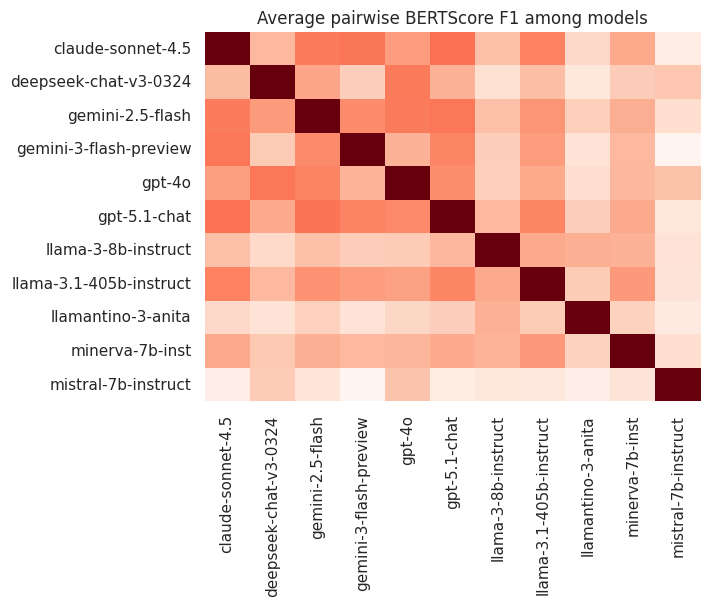

In [13]:
sns.heatmap(bertscore_df.fillna(1), cmap ="Reds", cbar = False).set(title= "Average pairwise BERTScore F1 among models")

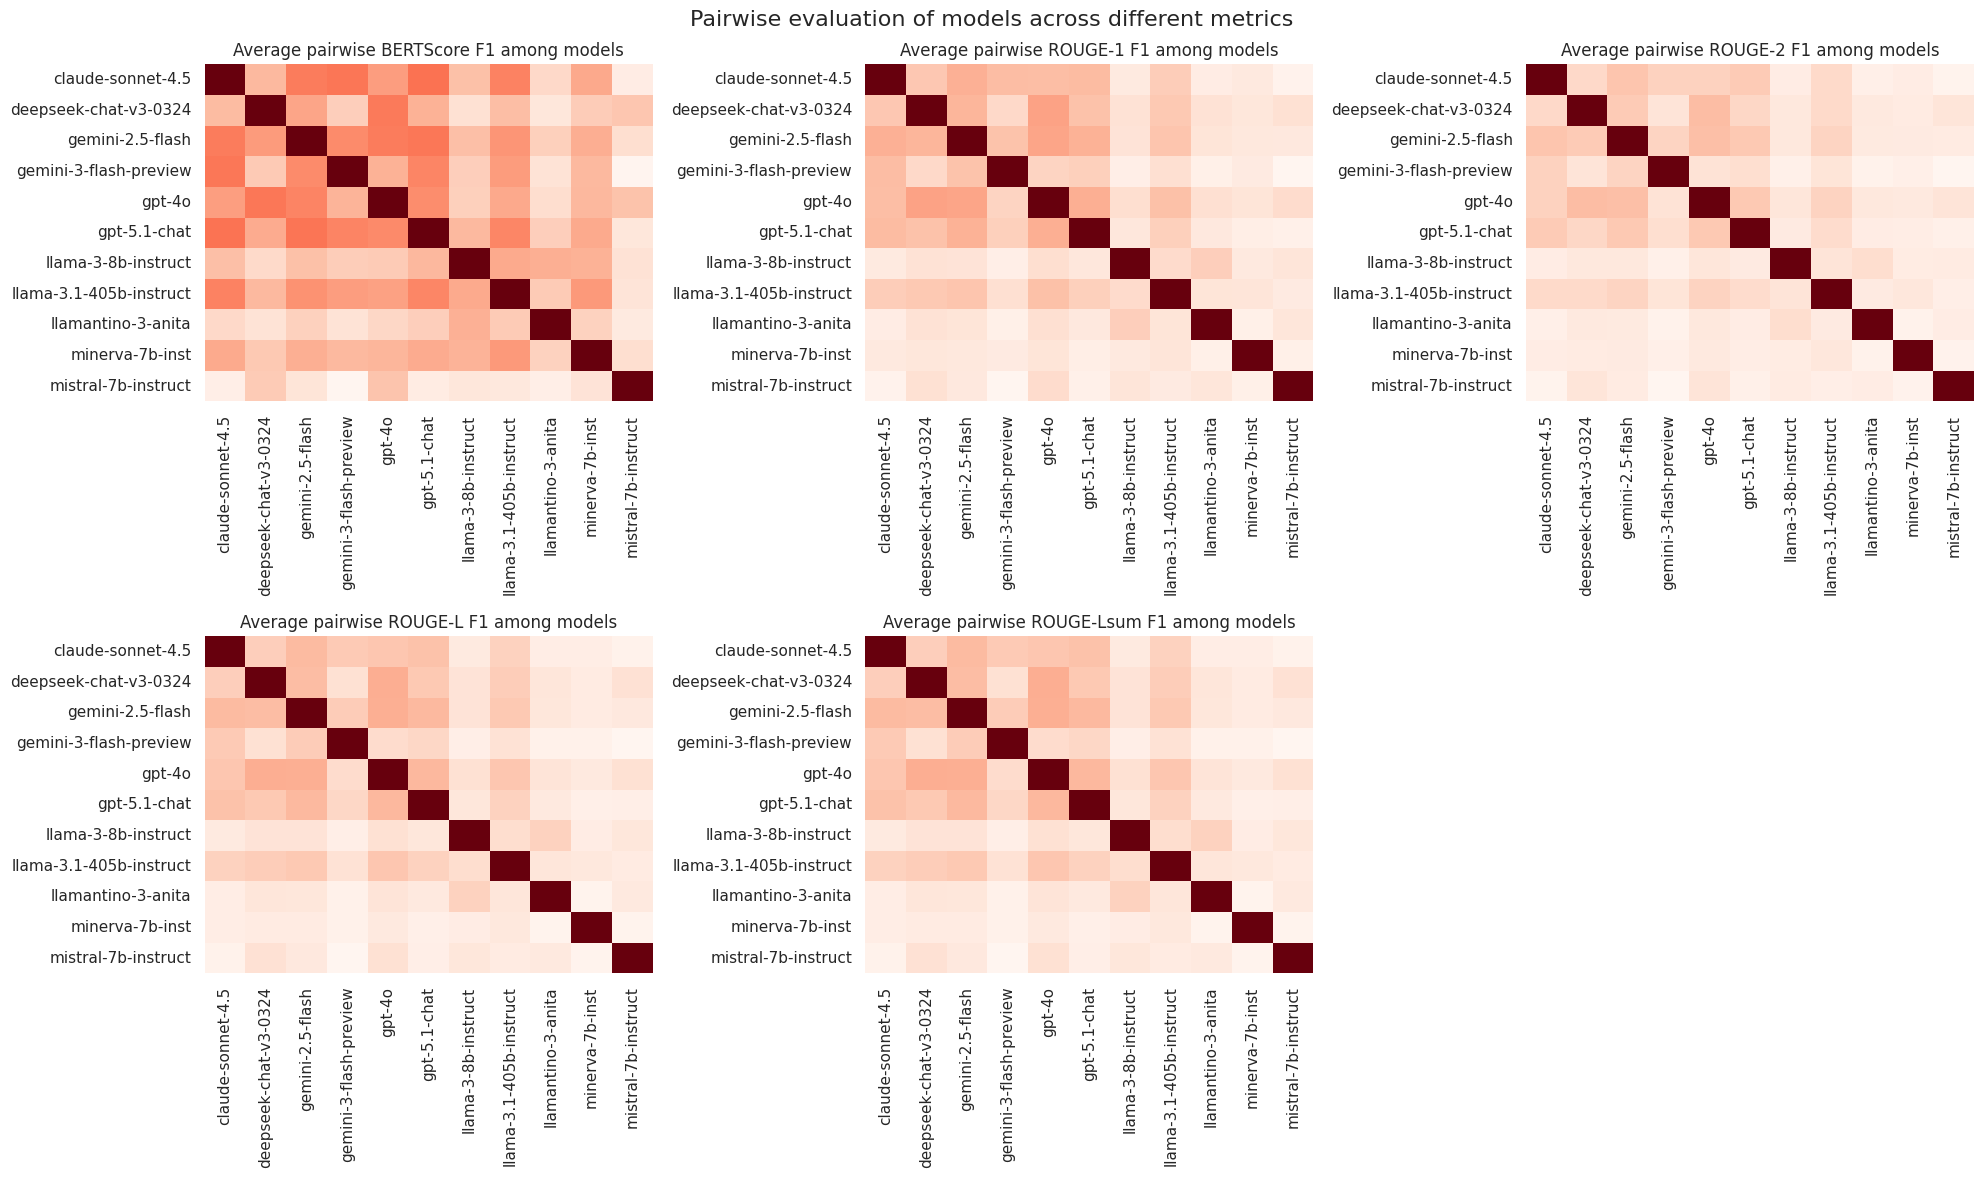

In [19]:
f1_matrices = {
    "BERTScore F1": bertscore_df,
    "ROUGE-1 F1": rouge_dfs["rouge1"],
    "ROUGE-2 F1": rouge_dfs["rouge2"],
    "ROUGE-L F1": rouge_dfs["rougeL"],
    "ROUGE-Lsum F1": rouge_dfs["rougeLsum"],
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for ax, (title, df) in zip(axes, f1_matrices.items()):
    sns.heatmap(df.fillna(1), cmap="Reds", cbar=False, ax=ax)
    ax.set_title(f"Average pairwise {title} among models")
    ax.set_xlabel("")
    ax.set_ylabel("")

# Hide the extra (6th) subplot since we have 5 metrics.
for ax in axes[len(f1_matrices):]:
    ax.axis("off")
plt.suptitle("Pairwise evaluation of models across different metrics", fontsize=16)
plt.tight_layout()
plt.show()

## Filter

In [26]:
import os 
import json
batches_path = "../data/batches4search"
all_data = []
for file in os.listdir(batches_path):
    if file.endswith(".json"):
        with open(os.path.join(batches_path, file), "r") as f:
            all_data.extend(json.load(f))

In [27]:
import re
import unicodedata
from typing import Literal 

def normalize_text(text: str) -> str:
    # Lowercase, strip accents, remove punctuation, and collapse spaces.
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^\w\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def term_in_definition(term: str, definition: str, mode: Literal["strict", "loose"] = "loose") -> bool:
    term_n = normalize_text(term)
    def_n = normalize_text(definition)
    if not term_n or not def_n:
        return False

    # Direct containment (exact phrase or partial substring).
    if mode == "loose":
        if term_n in def_n:
            return True

    # Containment after removing spaces (handles split/merged words).
    # term_compact = term_n.replace(" ", "")
    # def_compact = def_n.replace(" ", "")
    # if term_compact and term_compact in def_compact:
    #     return True

    elif mode == "strict":
        if term_n == def_n:
            return True
        # Token-level partial overlap (ignore very short tokens to reduce noise).
        term_tokens = [t for t in term_n.split() if len(t) >= 4 ]
        def_tokens = [t for t in def_n.split() if len(t) >= 4]
        for t in term_tokens:
            for d in def_tokens:
                if t in d or d in t:
                    return True

    return False

mode = "strict"
all_data_filter = [
    e for e in all_data
    if not term_in_definition(e.get("term", ""), e.get("term_definition", ""), mode = mode)
]

# Optional sanity check: how many entries were removed?
removed_count = len(all_data) - len(all_data_filter)
print(f"Removed: {removed_count} / {len(all_data)}")
print(f"Remaining entries {len(all_data_filter)}")

Removed: 789 / 1244
Remaining entries 455


In [28]:
all_data_filter

[{'term': 'Offerta al pubblico',
  'term_definition': 'Si tratta di un tipo di proposta di contratto rivolta, anziché a soggetti determinati, ad una generalità di destinatari: deve contenere tutti gli elementi essenziali del contratto proposto.'},
 {'term': 'Offerta non formale',
  'term_definition': 'In materia di obbligazioni, è la messa a disposizione della prestazione da parte del debitore, compiuta senza il rispetto delle formalità previste dagli artt. 1208 ss. c.c. per la costituzione in mora del creditore.'},
 {'term': 'Onerato',
  'term_definition': "Colui che ha l'obbligo di eseguire il legato a favore del legatario, cioè che gli deve far trasmettere la titolarità del bene o credito lasciato dal de cuius."},
 {'term': 'Operai',
  'term_definition': 'Assieme a dirigenti, quadri e impiegati, sono una delle quattro categorie di lavoratori subordinati previste dal codice civile: sono coloro cui è demandato il lavoro prettamente di manodopera.'},
 {'term': 'Ordine di protezione',
 

In [29]:
terms = [t["term"] for t in all_data_filter]

In [31]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

# Two lists of sentences


# Compute embeddings for both lists
embeddings1 = model.encode(terms)
embeddings2 = model.encode(terms)

# Compute cosine similarities
similarities = model.similarity(embeddings1, embeddings2)

/home/mattia.proietti/miniconda3/envs/bertscore_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1041.64it/s, Materializing param=pooler.dense.weight]                              
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [58]:


similarities[terms.index("Trattative")].topk(5)

torch.return_types.topk(
values=tensor([1.0000, 0.6948, 0.6821, 0.6785, 0.6522]),
indices=tensor([431, 226, 418,  99,  97]))

In [ ]:
import numpy as np

def extract_topk(term):
    return np.array(terms)[similarities[terms.index(term)].topk(20)[1]]

In [63]:
extract_topk("Trattative")

array(['Trattative', 'Caparra confirmatoria', 'Sublocazione',
       'Convenzione', 'Contratto tipico o nominato',
       'Avvenimento straordinario ed imprevedibile',
       'Offerta al pubblico', 'Subappalto', 'Transigere',
       'Conduttore o locatario', 'Usi locali', 'Mutuo', 'Riconduzione',
       'Patto di opzione', 'Reciproche concessioni (transazione)',
       'Pubblico incanto (diritto penale)', 'Tempo limitato',
       'Appaltatore', 'Trasferimento del portafoglio',
       'Verifica (appalto)'], dtype='<U53')

In [73]:
def compute_similarity_matrix(sentences, sentences2=None):
    embeddings = model.encode(sentences)
    embeddings2 = model.encode(sentences2) if sentences2 is not None else embeddings
    return model.similarity(embeddings, embeddings2)


def extract_topk(entry, similarities, k=20, side: Literal["term", "definition"] = "term"):
    
    if side == "term":
        entry_list = [e["term"] for e in all_data_filter]
    else:
        entry_list = [e["term_definition"] for e in all_data_filter]
    
    return np.array(entry_list)[similarities[entry_list.index(entry)].topk(k)[1]]

In [69]:
filtered_definitions = [e["term_definition"] for e in all_data_filter]
all_definitions = [e["term_definition"] for e in all_data]
similarities = compute_similarity_matrix(filtered_definitions, all_definitions)

<Axes: >

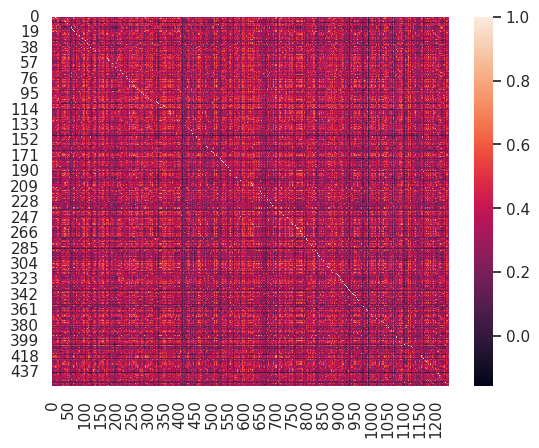

In [72]:
sns.heatmap(similarities)

In [ ]:
extract_topk("Trattative", similarities)

IndexError: index 1192 is out of bounds for axis 0 with size 455

: 